# Introduction to PyTorch

In this lab you will get a hands-on introduction to **PyTorch**, one of the most widely used deep learning frameworks in research and industry.

By the end of this lab you will be able to:

1. **Create and manipulate tensors** — PyTorch's core data structure
2. **Understand automatic differentiation (autograd)** — how PyTorch computes gradients for you (what happens during forward and backward pass)
3. **Build neural networks** with `nn.Module` and `nn.Sequential`
4. **Choose and use loss functions** appropriate for your task
5. **Use optimizers** (SGD, Adam) to update model weights
6. **Write a full training loop** from scratch
7. **Train a binary classifier** on a synthetic dataset and visualize the learned decision boundary

---

## Section 0: Setup & Imports

Let's start by importing everything we'll need. If any of these libraries are not installed yet, you can install them with:
```
pip install torch torchviz torchview scikit-learn matplotlib
```

We also fix random seeds so that your results are reproducible, and check whether a GPU is available (PyTorch will use it automatically if it is).

In [1]:
# Old friends
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# New friends
from torchviz import make_dot
from torchview import draw_graph
import torch
import torch.nn as nn
import torch.optim as optim

# Fix random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Default plot styling
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

Using device: cpu


---
## Section 1: Tensors

### What is a tensor?

A **tensor** is the fundamental data structure in PyTorch — think of it as a generalization of familiar mathematical objects:

| Dimensions | Name | Example |
|---|---|---|
| 0-D | Scalar | `3.14` |
| 1-D | Vector | `[1, 2, 3]` |
| 2-D | Matrix | `[[1, 2], [3, 4]]` |
| 3-D+ | Tensor | Image batch, video, etc. |

If you've used NumPy, tensors will feel very familiar. The key differences are:
- Tensors can live on a **GPU** for massive speedups during training
- Tensors support **automatic differentiation** (autograd) — PyTorch can automatically compute gradients through any computation you do with them

Let's explore the different ways to create tensors.

### 1a. Creating Tensors

There are many convenient constructors. Here are the ones you'll use most often:

In [2]:
# From a Python list or nested list
a = torch.tensor([1.0, 2.0, 3.0])
print("torch.tensor([1,2,3]):      ", a)

# All zeros — shape (2, 3)
b = torch.zeros(2, 3)
print("torch.zeros(2,3):\n", b)

# All ones
c = torch.ones(2, 3)
print("torch.ones(2,3):\n", c)

# Uniform random values in [0, 1)
d = torch.rand(2, 3)
print("torch.rand(2,3):\n", d)

# Standard normal random values (mean=0, std=1)
e = torch.randn(2, 3)
print("torch.randn(2,3):\n", e)

# Evenly spaced values (like np.arange)
f = torch.arange(0, 10, 2)
print("torch.arange(0,10,2):      ", f)

torch.tensor([1,2,3]):       tensor([1., 2., 3.])
torch.zeros(2,3):
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
torch.ones(2,3):
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
torch.rand(2,3):
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])
torch.randn(2,3):
 tensor([[ 1.1561,  0.3965, -2.4661],
        [ 0.3623,  0.3765, -0.1808]])
torch.arange(0,10,2):       tensor([0, 2, 4, 6, 8])


### 1b. Shapes, Data Types, and Device

Every tensor has three important attributes:
- `.shape` — dimensions of the tensor (same as NumPy)
- `.dtype` — the numerical type (float32, int64, etc.)
- `.device` — whether the tensor is on CPU or GPU

In [3]:
t = torch.randn(3, 4)   # 3 rows, 4 columns

print(f"Shape:  {t.shape}")    # torch.Size([3, 4])
print(f"Dtype:  {t.dtype}")    # torch.float32  (default for randn)
print(f"Device: {t.device}")   # cpu  (or cuda:0 if on GPU)

# You can create integer tensors too
int_tensor = torch.tensor([1, 2, 3])         # inferred as int64
float_tensor = torch.tensor([1.0, 2.0, 3.0]) # inferred as float32
print(f"\nint_tensor dtype:   {int_tensor.dtype}")
print(f"float_tensor dtype: {float_tensor.dtype}")

# Cast between types with .float(), .long(), .double(), etc.
print(f"int -> float: {int_tensor.float()}")

Shape:  torch.Size([3, 4])
Dtype:  torch.float32
Device: cpu

int_tensor dtype:   torch.int64
float_tensor dtype: torch.float32
int -> float: tensor([1., 2., 3.])


### 1c. Tensor Operations

PyTorch supports all the arithmetic you'd expect, including element-wise math, matrix multiplication, and combining tensors. These operations are written exactly like NumPy, so the transition is smooth.

In [4]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# Element-wise operations (broadcast over the whole tensor)
print("a + b  =", a + b)
print("a * b  =", a * b)
print("a ** 2 =", a ** 2)
print("a.sum()=", a.sum())
print("a.mean()=", a.mean())

# Matrix multiplication — the @ operator is clean and readable
A = torch.randn(3, 4)   # shape (3, 4)
B = torch.randn(4, 2)   # shape (4, 2)
C = A @ B               # shape (3, 2)  -- standard matrix multiply
print(f"\nA @ B shape: {C.shape}")

# Stacking tensors along a new dimension
x = torch.ones(3)
y = torch.zeros(3)
stacked = torch.stack([x, y], dim=0)    # shape (2, 3)
print(f"\ntorch.stack shape: {stacked.shape}")
print(stacked)

# Concatenating along an existing dimension
cat = torch.cat([x, y], dim=0)          # shape (6,)
print(f"\ntorch.cat result: {cat}")

a + b  = tensor([5., 7., 9.])
a * b  = tensor([ 4., 10., 18.])
a ** 2 = tensor([1., 4., 9.])
a.sum()= tensor(6.)
a.mean()= tensor(2.)

A @ B shape: torch.Size([3, 2])

torch.stack shape: torch.Size([2, 3])
tensor([[1., 1., 1.],
        [0., 0., 0.]])

torch.cat result: tensor([1., 1., 1., 0., 0., 0.])


### 1d. Reshaping Tensors

Reshaping is one of the most common operations in deep learning — for example, flattening an image into a vector before feeding it to a fully connected layer. PyTorch gives you several tools:

- `.view()` — reshape without copying data (fast; requires contiguous memory)
- `.reshape()` — same idea, but handles non-contiguous tensors too
- `.squeeze()` — remove dimensions of size 1
- `.unsqueeze()` — add a new dimension of size 1

In [5]:
t = torch.arange(12)         # [0, 1, 2, ..., 11]  shape: (12,)
print("Original:", t.shape)

# Reshape to 3x4
t2d = t.view(3, 4)
print("After .view(3,4):\n", t2d, "\nshape:", t2d.shape)

# Use -1 to let PyTorch infer one dimension automatically
t_flat = t2d.reshape(-1)     # back to 1D
print("\nAfter .reshape(-1):", t_flat.shape)

# unsqueeze: add a batch dimension at position 0
t_batch = t_flat.unsqueeze(0)   # shape: (1, 12)
print("\nAfter .unsqueeze(0):", t_batch.shape)

# squeeze: remove that extra dimension
t_squeezed = t_batch.squeeze(0) # shape: (12,)
print("After .squeeze(0):", t_squeezed.shape)

Original: torch.Size([12])
After .view(3,4):
 tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]) 
shape: torch.Size([3, 4])

After .reshape(-1): torch.Size([12])

After .unsqueeze(0): torch.Size([1, 12])
After .squeeze(0): torch.Size([12])


### 1e. Indexing Tensors

Tensor indexing works just like NumPy. You can use integer indices, slices, boolean masks, and fancy indexing.

In [6]:
t = torch.arange(9).reshape(3, 3).float()
print("Tensor t:\n", t)

# Single element
print("\nt[1, 2] =", t[1, 2])

# Slice: first two rows, all columns
print("t[:2, :] =\n", t[:2, :])

# Last column
print("t[:, -1] =", t[:, -1])

# Boolean masking — grab all elements greater than 4
mask = t > 4
print("\nElements > 4:", t[mask])

Tensor t:
 tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])

t[1, 2] = tensor(5.)
t[:2, :] =
 tensor([[0., 1., 2.],
        [3., 4., 5.]])
t[:, -1] = tensor([2., 5., 8.])

Elements > 4: tensor([5., 6., 7., 8.])


### 1f. Sending Tensors to a Device (GPU / CPU)

One of PyTorch's superpowers is that you can move tensors and models to a GPU with a single `.to(device)` call. If you don't have a GPU, no worries — everything runs on the CPU just fine. The code pattern below works universally regardless of your hardware.

In [7]:
# device was set at the top: cuda if available, else cpu
print(f"Device: {device}")

# Move a tensor to the selected device
t = torch.randn(3, 3)
t = t.to(device)
print(f"Tensor device: {t.device}")

# Note: for the rest of this lab we'll keep things on CPU for simplicity,
# but in practice you'd move both your model AND your data to the same device.

Device: cpu
Tensor device: cpu


---
## Section 2: Autograd — How PyTorch Computes Gradients

### The magic behind the scenes

Training a neural network means repeatedly computing gradients of a loss function with respect to all the model parameters, then using those gradients to update the parameters. For a large network this involves thousands of chain-rule applications.

PyTorch takes care of all of this automatically through its **autograd** engine. Here is the key idea:

> When PyTorch does math on tensors marked with `requires_grad=True`, it secretly records every operation in a **computational graph**. Calling `.backward()` walks *backwards* through this graph and computes gradients via the chain rule.

### The computational graph

Every time you write something like `L = v * (w**2 + 1)`, PyTorch builds a directed acyclic graph (DAG) where:
- **Leaf nodes** are the input tensors (`w`, `v`, …) — shown in blue/dark by torchviz.
- **Interior nodes** are operations (`MulBackward0`, `AddBackward0`, `PowBackward0`, …) — one per elementary operation in your expression.
- **Edges** encode data flow from inputs toward the output.

When `.backward()` is called, gradients flow in the **reverse** direction through the same graph, one node at a time, accumulating via the chain rule.

For a complete list of all possible graph nodes (i.e. every `grad_fn` type PyTorch can create) and the full mechanics of how the graph is built and traversed, see the official docs:
- **Autograd mechanics and API reference** — https://pytorch.org/docs/stable/notes/autograd.html

### 2a. A Simple Example

Let's differentiate:
$$L = \frac{1}{2} - w\,(1 - w)$$

Expanding: $L = \frac{1}{2} - w + w^2$, so analytically $\dfrac{dL}{dw} = -1 + 2w$.

At $w = 3$ we expect $\frac{dL}{dw} = -1 + 2 \times 3 = 5$.

**We'll look at the computational graph *before* calling `.backward()`** — so you can see exactly what PyTorch built from your expression.


In [8]:
w = torch.tensor(3.0, requires_grad=True)

# Define the function — PyTorch records every operation here
L = 1/2 - w * (1 - w)

print(f"w          = {w.item()}")
print(f"L          = {L.item():.4f}")


w          = 3.0
L          = 6.5000


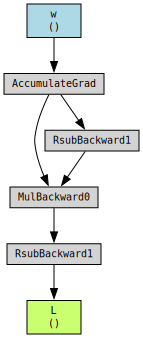

In [9]:
# Visualize the computational graph PyTorch has built so far.
dot = make_dot(L, params={"w": w, "L": L})
dot.render('example_2a',format='png')
dot

**Reading the graph:**

| Node label | Meaning |
|---|---|
| `w` (leaf, blue) | Our input tensor — a leaf because it was created directly, not by an operation |
| `RsubBackward1` | **Scalar minus tensor** (`scalar - tensor`). Appears *twice*: once for `(1 - w)` and once for `0.5 - w*(1-w)`. Gradient rule: negate the upstream gradient. |
| `MulBackward0` | Backward function for multiplication (`*`) |
| `AccumulateGrad` | Marks a leaf tensor whose gradient will be accumulated into `.grad` |

Every elementary PyTorch operation (add, mul, pow, exp, …) has a corresponding `*Backward*` node. When `.backward()` is called, PyTorch traverses these nodes **in reverse**, applying the chain rule at each one.

Full list of all possible nodes → **https://pytorch.org/docs/stable/autograd.html**  

In [10]:
# Now run backpropagation — gradients flow backwards through the graph above
L.backward()

print(f"dL/dw = {w.grad.item()}")   # Expected: -1 + 2*3 = 5.0


dL/dw = 5.0


### 2b. Multi-Variable Gradients

Let's scale up to a function with two inputs:
$$L = v \cdot \bigl(w_0^2 + 3w_1 + 1\bigr)$$

Partial derivatives at $w_0 = 2$, $w_1= 5$ and $v=1$:
- $\dfrac{\partial L}{\partial w_0} = v \cdot 2w_0 = 1 \cdot 2 \cdot 2 = 4$
- $\dfrac{\partial L}{\partial w_1} = v \cdot 3 = 3$
- $\dfrac{\partial L}{\partial v}\; = w_0^2 + 3w_1 + 1 = 4 + 15 + 1 = 20$

Again, **graph first** — then backward.


In [11]:
w = torch.tensor([2.0, 5.0], requires_grad=True)
v = torch.tensor(1.0, requires_grad=True)

L = v * (w[0]**2 + 3*w[1] + 1)


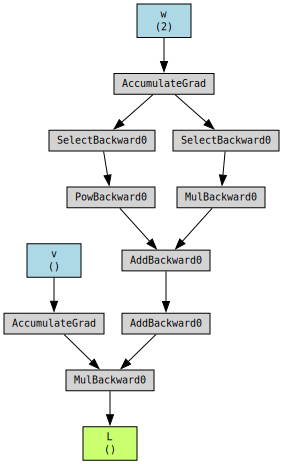

In [12]:
dot = make_dot(L, params={"w": w, "L": L, "v": v})
dot.render('example_2b',format='png')
dot

Notice the graph is deeper now — more operations means more nodes. The gradient still flows back through each one in turn. Let's verify the results:


In [13]:
L.backward()

print("w.grad =", w.grad)   # Expected: tensor([4., 3.])
print("v.grad =", v.grad)   # Expected: tensor([20.])


w.grad = tensor([4., 3.])
v.grad = tensor(20.)


The gradients match our hand-computed values exactly. No matter how complicated your model is, `.backward()` automatically computes the correct gradient for every parameter.


---
## Section 3: Building Neural Networks

### `nn.Module`: the building block of every PyTorch network

All neural networks in PyTorch are subclasses of `nn.Module`. A module is essentially a **container for parameters and computation**:

- **Layers** like `nn.Linear` (fully connected), `nn.Conv2d` (convolution), etc. are themselves `nn.Module`s
- When you call a module like a function — `module(x)` — it internally runs the `forward()` method
- Modules automatically track their parameters so the optimizer can update them

The quickest way to define a simple network is `nn.Sequential`, which chains modules together in order.

### 3a. Building a Network with `nn.Sequential`

This network has:
1. A **linear layer** with 10 inputs and 20 outputs (a learned weight matrix + bias)
2. A **ReLU** activation (non-linearity: $\text{ReLU}(x) = \max(0, x)$)
3. Another **linear layer** with 20 inputs and 1 output

In [ ]:
model = nn.Sequential(
    nn.Linear(10, 20),   # 10 input features -> 20 hidden units
    nn.ReLU(),           # non-linearity
    nn.Linear(20, 1)     # 20 hidden units -> 1 output
)

print(model)

In [ ]:
# Run a forward pass so PyTorch builds the computational graph, then visualise it
x = torch.randn(500, 10, requires_grad=True)
y_pred = model(x)

dot = make_dot(y_pred,params={**dict(model.named_parameters()), "x": x, "y_pred": y_pred})
dot

### 3b. Inspecting Model Parameters

Every `nn.Linear(in, out)` layer has:
- A **weight matrix** of shape `(out, in)`
- A **bias vector** of shape `(out,)`

You can iterate over all parameters to see their names and shapes, which is very handy for debugging.

In [ ]:
# Total number of learnable parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

# Inspect each parameter's name and shape
print()
for name, param in model.named_parameters():
    print(f"{name:30s}: shape {param.shape}")

### 3c. Visualizing the Network with `torchview`

`torchview` renders a beautiful diagram of the forward pass, showing the data shape at each step. Just tell it the input size and it traces through the model.

In [ ]:
# input_size=(1, 10) means: batch of 1, each sample has 10 features
graph = draw_graph(model, input_size=(500, 10), expand_nested=True)
graph.visual_graph

### 3d. Custom Networks with `nn.Module`

`nn.Sequential` is great for simple pipelines, but for anything more complex (skip connections, multiple inputs/outputs, conditional logic, etc.) you'll want to define a **custom class** that inherits from `nn.Module`.

You define two methods:
- `__init__`: declare the layers as attributes
- `forward`: describe how data flows through the layers

PyTorch automatically registers everything you define in `__init__` as parameters.

In [ ]:
class MyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()                                      # always call this first!
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, output_dim)         # no activation in second layer
        self.relu   = nn.ReLU()
    
    def forward(self, x):
        # Data flows: x -> layer1 -> ReLU -> layer2 -> output
        x = self.relu(self.layer1(x))   # hidden layer + activation
        x = self.layer2(x)              # output layer — no activation
        return x

# Instantiate the network
net = MyNetwork(input_dim=10, hidden_dim=20, output_dim=1)

# Run a forward pass on a batch of 5 random samples
x_test = torch.randn(500, 10)   # 5 samples, each with 10 features
out = net(x_test)

print(f"Input shape:  {x_test.shape}")
print(f"Output shape: {out.shape}")
print(f"Output:\n{out}")

---
## Section 4: Loss Functions

A **loss function** (also called a cost or objective function) measures how wrong our model's predictions are. Training a neural network is really just an optimization problem:

> **Minimize** the loss function **over** the model parameters.

Choosing the right loss function depends on your task:

| Task | Common Loss | PyTorch class |
|---|---|---|
| Regression | Mean Squared Error | `nn.MSELoss()` |
| Binary classification | Binary Cross-Entropy | `nn.BCELoss()` |
| Multi-class classification | Cross-Entropy | `nn.CrossEntropyLoss()` |

Let's visualize both regression and classification losses.

### 4a. Mean Squared Error (MSE) — for Regression

MSE penalizes predictions proportionally to the square of how far off they are:
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

The parabolic shape means predictions that are far from the truth receive very strong gradient signals — the model gets pushed hard to correct large errors.

In [ ]:
mse = nn.MSELoss()

y_true = torch.tensor([3.0])          # the true value
predictions = torch.linspace(0, 6, 200)  # range of possible predictions

# Compute MSE loss at each prediction value
losses = [mse(pred.unsqueeze(0), y_true).item() for pred in predictions]

plt.figure(figsize=(8, 4))
plt.plot(predictions.numpy(), losses, 'steelblue', linewidth=2.5)
plt.axvline(x=3.0, color='crimson', linestyle='--', label='True value = 3.0')
plt.xlabel('Prediction')
plt.ylabel('MSE Loss')
plt.title('MSE Loss vs. Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4b. Binary Cross-Entropy (BCE) — for Classification

For binary classification, we output a **probability** $p \in [0, 1]$ that the sample belongs to the positive class. BCE measures how surprised we should be given the true label:

$$\text{BCE} = -[y \log(p) + (1-y) \log(1-p)]$$

When the true label is 1 and we predict probability 0 (completely wrong and confident) — the loss is infinite. That's a feature, not a bug!

In [ ]:
bce = nn.BCELoss()

y_true = torch.tensor([1.0])          # true label is 1 (positive class)
probs  = torch.linspace(0.01, 0.99, 200)   # predicted probability P(y=1)

losses_bce = [bce(p.unsqueeze(0), y_true).item() for p in probs]

plt.figure(figsize=(8, 4))
plt.plot(probs.numpy(), losses_bce, 'darkorange', linewidth=2.5)
plt.xlabel('Predicted Probability P(y=1)')
plt.ylabel('BCE Loss')
plt.title('Binary Cross-Entropy Loss  (true label = 1)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice how the loss **explodes** as the predicted probability approaches 0 (being very confidently wrong). This is intentional — it creates strong gradient signals that push the model hard in the right direction whenever it makes a confident mistake.

---
## Section 5: Optimizers

An **optimizer** takes the gradients computed by `.backward()` and uses them to update the model's parameters. The update rule differs between optimizers:

- **SGD** (Stochastic Gradient Descent): simple, classic
  $$\theta \leftarrow \theta - \alpha \cdot \nabla_\theta \mathcal{L}$$
- **Adam**: adapts the learning rate per-parameter using momentum; usually converges faster in practice

Both are available in `torch.optim`. The pattern is always the same:
```python
optimizer = optim.Adam(model.parameters(), lr=1e-3)
optimizer.zero_grad()   # clear old gradients
loss.backward()         # compute new gradients
optimizer.step()        # update parameters
```

### 5a. Watching SGD Minimize a Simple Function

Let's watch the optimizer in action. We have a single parameter $w$ and we want to minimize $w^2$ (minimum at $w = 0$). Starting from $w = 5$, each optimizer step should nudge $w$ closer to zero.

In [ ]:
# A single learnable parameter initialized to 5
w = nn.Parameter(torch.tensor(5.0))
optimizer = optim.SGD([w], lr=0.1)

history = [w.item()]   # track how w changes

for i in range(20):
    loss = w ** 2           # objective: minimize w²
    optimizer.zero_grad()   # clear old gradients
    loss.backward()         # compute gradient: d(w²)/dw = 2w
    optimizer.step()        # update: w <- w - lr * 2w
    history.append(w.item())

plt.figure(figsize=(8, 4))
plt.plot(history, 'o-', color='steelblue', linewidth=2, markersize=6)
plt.axhline(y=0, color='crimson', linestyle='--', label='Minimum (w=0)')
plt.xlabel('Optimization Step')
plt.ylabel('Parameter w')
plt.title('SGD Minimizing w² — Parameter Moving Towards Zero')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final w = {w.item():.4f}")

---
## Section 6: The Training Loop

### The heart of deep learning

Everything we've covered so far — tensors, autograd, networks, losses, optimizers — comes together in the **training loop**.

Here we use **full-batch gradient descent**: all $N$ training samples are fed through the model at once, the loss is computed over the entire dataset, and the weights are updated once per epoch. This is the plain vanilla implementation — simple to understand, but not what is used in practice.

In practice, **mini-batch gradient descent** is the standard: the dataset is split into small batches (typically 32–256 samples) and one gradient update is performed per batch. Each epoch therefore consists of $\lfloor N / b \rfloor$ update steps, where $b$ is the batch size. This is more computationally efficient and often converges better due to the noise in the gradient estimates. We use full-batch here to keep the code as simple as possible.

Every **epoch** (one full pass over the training data) consists of four steps:

| Step | What happens |
|---|---|
| 1. Forward pass | Feed data through the model to get predictions |
| 2. Compute loss | Measure how wrong the predictions are |
| 3. Backward pass | Compute gradients via backpropagation |
| 4. Optimizer step | Update model weights using the gradients |

In [ ]:
# ============================================================
# TEMPLATE: Full-Batch Gradient Descent Training Loop
# ============================================================
#
# model     = your_model
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# criterion = nn.MSELoss()   # or BCELoss, CrossEntropyLoss, ...
# X, y      = your training data as tensors (full dataset)
#
# for epoch in range(num_epochs):
#     optimizer.zero_grad()       # ⚠️  MUST zero gradients before backward!
#
#     y_pred = model(X)           # 1. Forward pass (entire dataset)
#     loss   = criterion(y_pred, y)  # 2. Compute loss
#
#     loss.backward()             # 3. Compute gradients (backprop)
#     optimizer.step()            # 4. Update weights
#
#     if epoch % 100 == 0:
#         print(f"Epoch {epoch:>4}, Loss: {loss.item():.4f}")

print("Template displayed — let's use it for real in Section 7!")

---
## Section 7: Full Working Example — Binary Classification

Let's put everything together and train a real neural network!

We'll use the classic **Two Moons** dataset — two interlocking crescent shapes in 2D. No linear classifier can separate these classes, but a neural network with non-linear activations can learn to do it perfectly.

By the end of this section you'll have a fully trained classifier and a beautiful visualization of the decision boundary it learned.

### 7a. Generate and Visualize the Data

First, let's generate 500 samples from the two moons distribution and take a look at them.

In [ ]:
# Generate the dataset
X_np, y_np = make_moons(n_samples=500, noise=0.2, random_state=42)

# Visualize
plt.figure(figsize=(7, 5))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
            color='steelblue', alpha=0.7, edgecolors='k', linewidths=0.5, label='Class 0')
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
            color='crimson',   alpha=0.7, edgecolors='k', linewidths=0.5, label='Class 1')
plt.title('Two Moons Dataset', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Convert to PyTorch tensors
X = torch.FloatTensor(X_np)
y = torch.FloatTensor(y_np)

print(f"X shape: {X.shape}, y shape: {y.shape}")

### 7b. Define the Model

Our classifier takes 2 input features (the x, y coordinates) and outputs a single probability. We use a **Sigmoid** activation at the end to squash the output into the range $[0, 1]$, which we can interpret as $P(\text{class}=1)$.

Architecture:
- Input: 2 features
- Hidden Layer 1: 16 units + ReLU
- Hidden Layer 2: 16 units + ReLU
- Output: 1 unit + Sigmoid

In [ ]:
class MoonClassifier(nn.Module):
    """A simple feedforward network for binary classification on the Two Moons dataset."""
    
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16),    # 2 input features -> 16 hidden units
            nn.ReLU(),
            nn.Linear(16, 16),   # another hidden layer
            nn.ReLU(),
            nn.Linear(16, 1),    # 16 hidden units -> 1 output logit
            nn.Sigmoid()         # squash output to [0, 1]  (probability)
        )
    
    def forward(self, x):
        return self.network(x)

# Instantiate the model
model = MoonClassifier()

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

### 7c. Train the Model

Now we apply the training loop template. We'll train for 500 epochs using Adam and Binary Cross-Entropy loss. Since we're using full-batch GD, each epoch is one gradient update step over all 500 samples.

In [ ]:
criterion  = nn.BCELoss()
optimizer  = optim.Adam(model.parameters(), lr=0.01)
losses     = []
num_epochs = 500
y_pred = model(X).squeeze()                 
loss = criterion(y_pred, y)

# Visualize the graph
dot = make_dot(loss, params=dict(model.named_parameters()))
dot

In [ ]:
for epoch in range(num_epochs):
    optimizer.zero_grad()                # zero gradients

    y_pred = model(X).squeeze()          # forward pass (full dataset)
    loss   = criterion(y_pred, y)        # compute loss

    loss.backward()                      # backpropagation
    optimizer.step()                     # update weights

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:>4}/{num_epochs} | Loss: {loss.item():.4f}")

# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Training Loss over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7d. Evaluate and Visualize the Decision Boundary

The real test of our classifier is what it learned about the structure of the data. We'll visualize two things:
1. **Probability heatmap** — the raw $P(\text{class}=1)$ prediction over the entire 2D space
2. **Decision boundary** — the hard threshold at $p = 0.5$ that separates the predicted classes

In [ ]:
def plot_decision_boundary(model, X_np, y_np):
    """Plot the learned decision boundary of a binary classifier."""
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                          np.linspace(y_min, y_max, 400))

    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

    with torch.no_grad():   # no need to build the graph during inference
        probs = model(grid_tensor).numpy().reshape(xx.shape)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: probability heatmap
    im = axes[0].contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8)
    axes[0].scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
                    color='royalblue', edgecolors='k', linewidths=0.5, alpha=0.8, label='Class 0')
    axes[0].scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
                    color='firebrick', edgecolors='k', linewidths=0.5, alpha=0.8, label='Class 1')
    plt.colorbar(im, ax=axes[0], label='P(class=1)')
    axes[0].set_title('Predicted Probability Heatmap', fontsize=13)
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)

    # Right panel: hard decision boundary at p=0.5
    axes[1].contourf(xx, yy, probs > 0.5, levels=1, cmap='RdBu_r', alpha=0.3)
    axes[1].contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
    axes[1].scatter(X_np[y_np==0, 0], X_np[y_np==0, 1],
                    color='royalblue', edgecolors='k', linewidths=0.5, alpha=0.8, label='Class 0')
    axes[1].scatter(X_np[y_np==1, 0], X_np[y_np==1, 1],
                    color='firebrick', edgecolors='k', linewidths=0.5, alpha=0.8, label='Class 1')
    axes[1].set_title('Decision Boundary  (threshold = 0.5)', fontsize=13)
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

plot_decision_boundary(model, X_np, y_np)